In [21]:
import pandas as pd  
import matplotlib.pyplot as plt  

file_path = "datasets/incidents.csv" 
incidents = pd.read_csv(file_path)

print(incidents.head())

print(incidents.info())

print(incidents.columns)


   Incident_ID  Customer_ID  Age  Gender  Season Weather      Activity  \
0            0         2679   33    Male  Winter   Foggy        Skiing   
1            1         4257   36  Female  Summer   Sunny        Hiking   
2            2         7924   47  Female  Winter   Foggy  Snowboarding   
3            3         7224   56    Male  Summer   Sunny        Hiking   
4            4         9785   17    Male  Summer   Windy      Climbing   

     Slope_Name Slope_Difficulty   Skill_Level Protective_Gear     Injuries  \
0    Bunny Hill             Easy      Beginner          Helmet       Sprain   
1  Devil’s Drop           Expert      Beginner          Helmet     Fracture   
2   Thunder Run         Advanced      Beginner          Helmet       Sprain   
3   Thunder Run         Advanced  Intermediate          Helmet     Fracture   
4    Blue Ridge     Intermediate      Beginner             NaN  Head Injury   

   Injury_Severity  Response_Time Hospital_Transport  Hospital_Stay_Length  
0  

In [2]:
print("\nMissing Values Per Column:")
print(incidents.isnull().sum())

print("\nNumerical Data Summary:")
print(incidents.describe())

print("\nCategorical Data Summary:")
print(incidents.describe(include='object'))


Missing Values Per Column:
Incident_ID               0
Customer_ID               0
Age                       0
Gender                    0
Season                    0
Weather                   0
Activity                  0
Slope_Name                0
Slope_Difficulty          0
Skill_Level               0
Protective_Gear         349
Injuries                  0
Injury_Severity           0
Response_Time             0
Hospital_Transport        0
Hospital_Stay_Length      0
dtype: int64

Numerical Data Summary:
       Incident_ID  Customer_ID          Age  Injury_Severity  Response_Time  \
count  1000.000000  1000.000000  1000.000000      1000.000000    1000.000000   
mean    499.500000  5627.834000    37.122000         5.631000      14.238000   
std     288.819436  2589.633228    12.906343         1.950036       3.754924   
min       0.000000  1022.000000    15.000000         2.000000       6.000000   
25%     249.750000  3368.500000    26.000000         4.000000      11.000000   
50%   

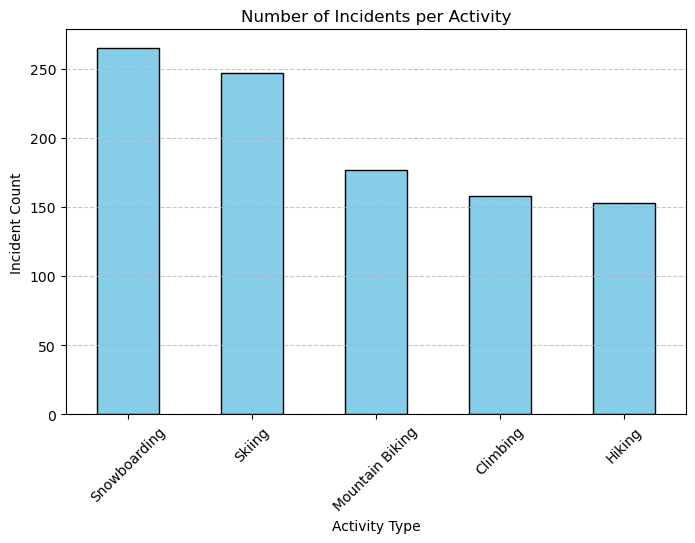

In [3]:
activity_counts = incidents['Activity'].value_counts()

plt.figure(figsize=(8, 5))
activity_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Incidents per Activity')
plt.xlabel('Activity Type')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

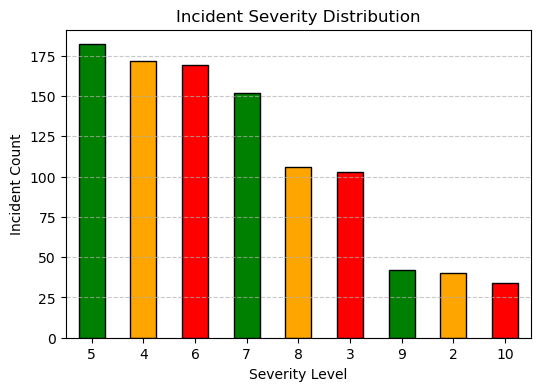

In [4]:
severity_counts = incidents['Injury_Severity'].value_counts()

plt.figure(figsize=(6, 4))
severity_counts.plot(kind='bar', color=['green', 'orange', 'red'], edgecolor='black')
plt.title('Incident Severity Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Incident Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

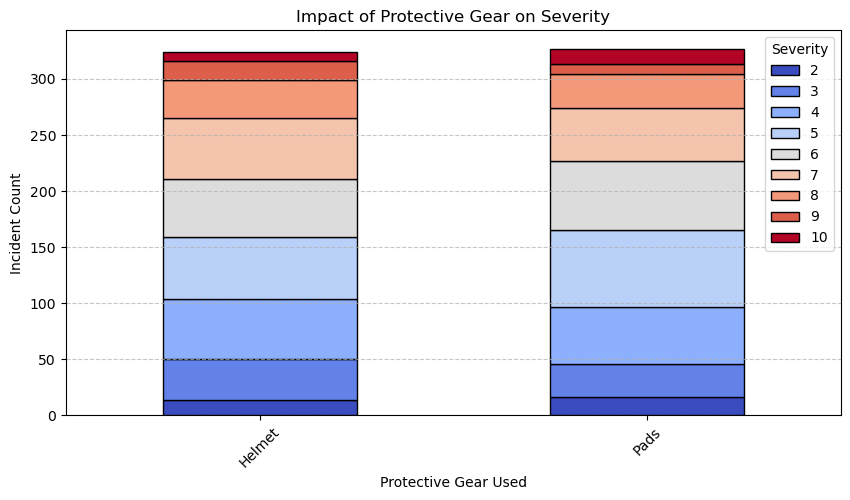

In [5]:
gear_severity = pd.crosstab(incidents['Protective_Gear'], incidents['Injury_Severity'])

gear_severity.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='coolwarm', edgecolor='black')
plt.title('Impact of Protective Gear on Severity')
plt.xlabel('Protective Gear Used')
plt.ylabel('Incident Count')
plt.xticks(rotation=45)
plt.legend(title='Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

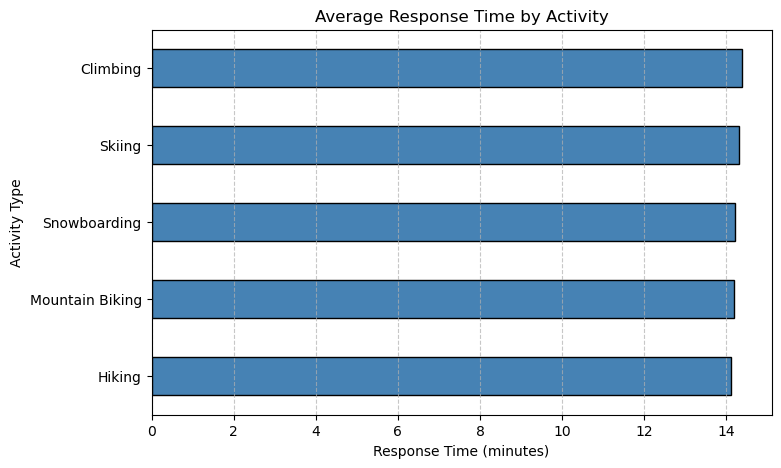

In [6]:
response_times = incidents.groupby('Activity')['Response_Time'].mean().sort_values()

plt.figure(figsize=(8, 5))
response_times.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Response Time by Activity')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Activity Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

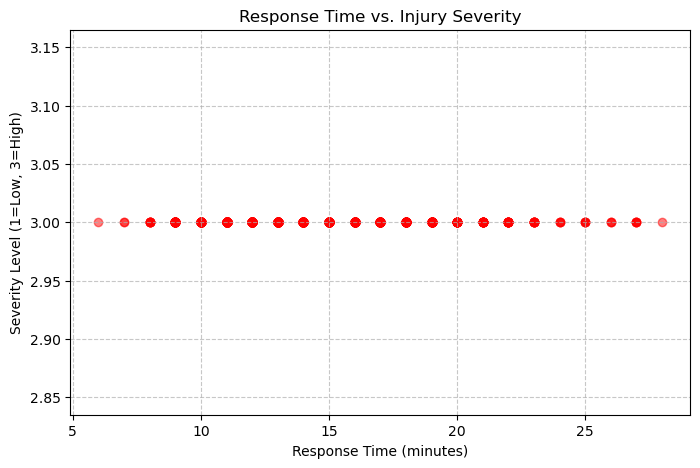

In [7]:
severity_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Severe': 3}

incidents['Severity_Numeric'] = incidents['Injury_Severity'].map(severity_mapping)

incidents['Severity_Numeric'] = incidents['Severity_Numeric'].fillna(3)  
incidents['Severity_Numeric'] = incidents['Severity_Numeric'].astype(int)  

plt.figure(figsize=(8, 5))
plt.scatter(incidents['Response_Time'], incidents['Severity_Numeric'], alpha=0.5, color='red')
plt.title('Response Time vs. Injury Severity')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Severity Level (1=Low, 3=High)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
import seaborn as sns

# Convert "Severity" to numeric levels
severity_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
incidents['Severity_Numeric'] = incidents['Injury_Severity'].map(severity_mapping)

# Convert other categorical features to numeric using encoding
incidents['Activity_Code'] = incidents['Activity'].astype('category').cat.codes  # Encode activities
incidents['Skill_Level_Code'] = incidents['Skill_Level'].astype('category').cat.codes  # Encode skill levels
incidents['Slope_Difficulty_Code'] = incidents['Slope_Difficulty'].astype('category').cat.codes  # Encode slope difficulty
incidents['Protective_Gear_Code'] = incidents['Protective_Gear'].astype('category').cat.codes  # Encode protective gear types

# Convert "Response_Time" to integer (assuming it's in minutes and has no missing values)
incidents['Response_Time'] = incidents['Response_Time'].astype(float)  # Convert time to float


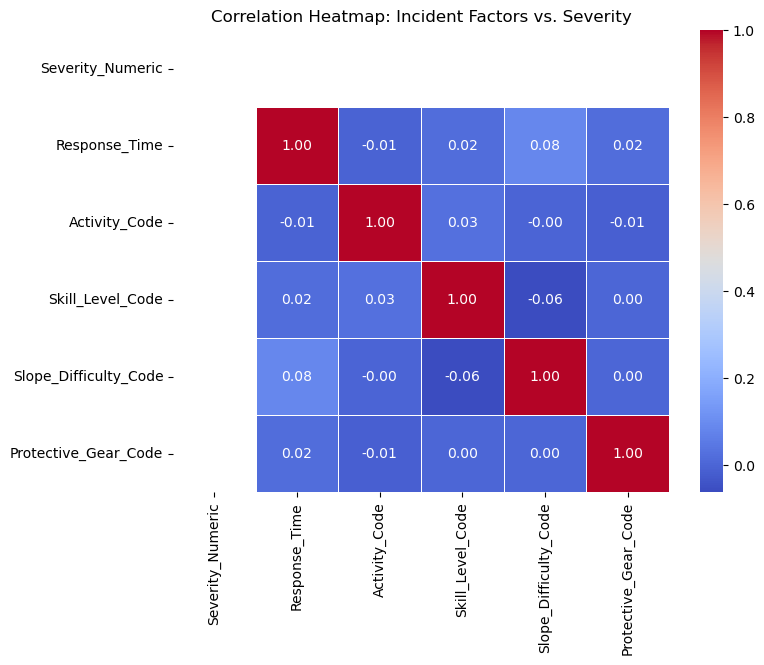

In [15]:
# Select only numeric columns for correlation
correlation_data = incidents[['Severity_Numeric', 'Response_Time', 'Activity_Code', 
                              'Skill_Level_Code', 'Slope_Difficulty_Code', 'Protective_Gear_Code']]

# Compute the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Customize the heatmap
plt.title("Correlation Heatmap: Incident Factors vs. Severity")
plt.show()


In [31]:
# --- Preprocessing ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

# Assume 'incidents' DataFrame is already loaded
print("Before removing NaNs:")
print(incidents.head())

# Remove rows with NaNs in the key columns (adjust this list based on your dataset)
columns_to_use = ['Age', 'Skill_Level', 'Protective_Gear', 'Injury_Severity', 
                  'Season', 'Injuries', 'Response_Time', 'Hospital_Stay_Length']
incidents = incidents.dropna(subset=columns_to_use)
print("\nAfter removing NaNs:")
print(incidents.head())
print(f"Rows left: {len(incidents)}")

# --- Analysis 1: Severity Prediction Model ---
print("\n--- Severity Prediction Model ---")

# Map Skill_Level and Protective_Gear to numeric codes
# (Update the dictionaries if there are additional levels in your dataset.)
incidents['Skill_Level_Code'] = incidents['Skill_Level'].map({
    'Beginner': 0, 
    'Intermediate': 1, 
    'Advanced': 2
})
incidents['Protective_Gear_Code'] = incidents['Protective_Gear'].map({
    'None': 0, 
    'Helmet': 1
})

# Scale Age (assumed range: min=15, max=59)
incidents['Age_Scaled'] = (incidents['Age'] - 15) / (59 - 15)

# Bin Injury_Severity into categories (assuming Injury_Severity is numeric on a 1-10 scale)
bins = [1, 4, 7, 10]
labels = ['Low', 'Medium', 'High']
incidents['Severity_Binned'] = pd.cut(incidents['Injury_Severity'], bins=bins, labels=labels, include_lowest=True)

# At this point, it's a good idea to check how many rows have NaNs in our new mapped columns:
print("\nUnique Skill_Level_Code values:", incidents['Skill_Level_Code'].unique())
print("Unique Protective_Gear_Code values:", incidents['Protective_Gear_Code'].unique())
print("Unique Severity_Binned values:", incidents['Severity_Binned'].unique())

# Drop any rows with NaN values in the features used for modeling
model_data = incidents.dropna(subset=['Age_Scaled', 'Skill_Level_Code', 'Protective_Gear_Code', 'Severity_Binned'])
print("\nRows after dropping rows with NaN in model features:", len(model_data))

# Features (X) and target (y) for the prediction model
X1 = model_data[['Age_Scaled', 'Skill_Level_Code', 'Protective_Gear_Code']]
y1 = model_data['Severity_Binned']

print("\nFeatures sample:")
print(X1.head())
print("\nTarget sample:")
print(y1.head())

# --- Train/Test Split and Model Training ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Split data (80% train, 20% test)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Train logistic regression model
model1 = LogisticRegression(multi_class='multinomial', max_iter=1000)
model1.fit(X1_train, y1_train)
print("\nModel trained! Accuracy:", model1.score(X1_test, y1_test))

# Predict for a sample input: Age=40, Beginner, Helmet
new_data = pd.DataFrame({
    'Age_Scaled': [(40 - 15) / (59 - 15)], 
    'Skill_Level_Code': [0], 
    'Protective_Gear_Code': [1]
})
prediction = model1.predict(new_data)
print(f"Prediction for Age=40, Beginner, Helmet: {prediction[0]}")


Before removing NaNs:
   Incident_ID  Customer_ID  Age  Gender  Season Weather      Activity  \
0            0         2679   33    Male  Winter   Foggy        Skiing   
1            1         4257   36  Female  Summer   Sunny        Hiking   
2            2         7924   47  Female  Winter   Foggy  Snowboarding   
3            3         7224   56    Male  Summer   Sunny        Hiking   
4            4         9785   17    Male  Summer   Windy      Climbing   

     Slope_Name Slope_Difficulty   Skill_Level Protective_Gear     Injuries  \
0    Bunny Hill             Easy      Beginner          Helmet       Sprain   
1  Devil’s Drop           Expert      Beginner          Helmet     Fracture   
2   Thunder Run         Advanced      Beginner          Helmet       Sprain   
3   Thunder Run         Advanced  Intermediate          Helmet     Fracture   
4    Blue Ridge     Intermediate      Beginner            None  Head Injury   

   Injury_Severity  Response_Time Hospital_Transport  Hosp


--- Seasonal Risk Analysis ---
Injury Counts by Season:
Injuries  Concussion  Fracture  Head Injury  Sprain
Season                                             
Summer             0       258           70     160
Winter           167       162            0     183


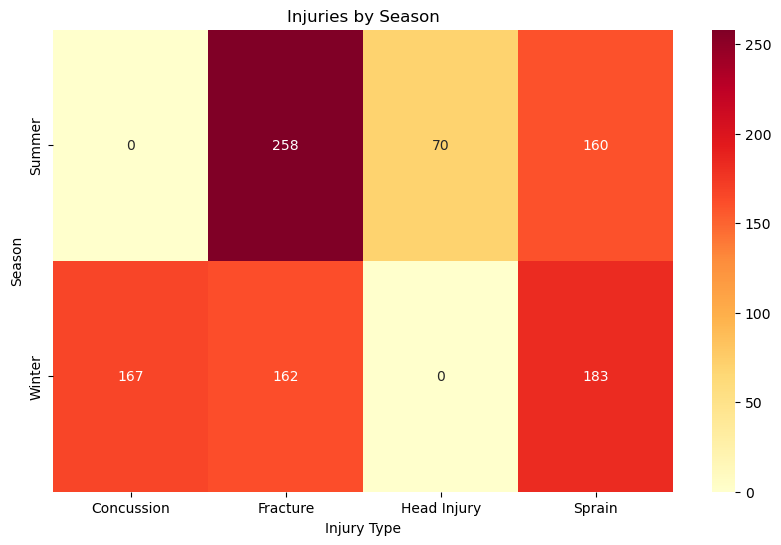

In [33]:
print("\n--- Seasonal Risk Analysis ---")

# Create a contingency table (crosstab) for injuries by season
injury_season_counts = pd.crosstab(incidents['Season'], incidents['Injuries'])
print("Injury Counts by Season:")
print(injury_season_counts)

# Plot the heatmap of injury counts by season
plt.figure(figsize=(10, 6))
sns.heatmap(injury_season_counts, annot=True, cmap='YlOrRd', fmt='d')
plt.title('Injuries by Season')
plt.xlabel('Injury Type')
plt.ylabel('Season')
plt.show()


In [35]:
print("\n--- Correlation Analysis with Protective Gear ---")

# Create a contingency table between Protective_Gear and Severity_Binned
gear_severity_table = pd.crosstab(incidents['Protective_Gear'], incidents['Severity_Binned'])
print("Gear vs Severity Table:")
print(gear_severity_table)

# Perform a chi-square test on the contingency table
chi2, p, dof, expected = chi2_contingency(gear_severity_table)
print("\nChi-Square Test Results:")
print(f"Chi2 Statistic: {chi2:.2f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

if p < 0.05:
    print("\nResult: There is a statistically significant association between protective gear usage and injury severity (p < 0.05).")
else:
    print("\nResult: No statistically significant association was found between protective gear usage and injury severity (p >= 0.05).")



--- Correlation Analysis with Protective Gear ---
Gear vs Severity Table:
Severity_Binned  Low  Medium  High
Protective_Gear                   
Helmet           104     161    59
None             114     165    70
Pads              97     177    53

Chi-Square Test Results:
Chi2 Statistic: 3.52
P-value: 0.4745
Degrees of Freedom: 4
Expected Frequencies:
[[102.06  162.972  58.968]
 [109.935 175.547  63.518]
 [103.005 164.481  59.514]]

Result: No statistically significant association was found between protective gear usage and injury severity (p >= 0.05).



--- Time-to-Hospital Analysis ---
Features (first 5 rows):
   Response_Time
0             15
1             23
2             13
3              9
4             10

Target (first 5 rows):
0    0
1    0
2    1
3    0
4    4
Name: Hospital_Stay_Length, dtype: int64

Linear Regression Model trained!
Slope (Coefficient): 0.01
Intercept: 0.16


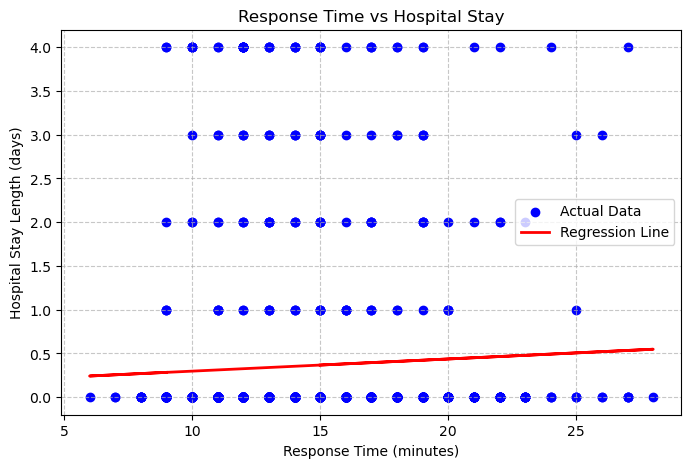

R-squared: 0.00
Interpretation: Longer response time is associated with longer hospital stay.
